# Workload Model

Produces every figure in `workload_model.md`. CFPB data is fetched live on each run, and each request's fetch time is appended to `data/fetch_log.csv` for logging the latest run.

## Configuration

In [1]:
import ast, math
from datetime import date, datetime
from pathlib import Path
from zoneinfo import ZoneInfo

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

API_URL = "https://www.consumerfinance.gov/data-research/consumer-complaints/search/api/v1/"
YEAR = 2025

PEER_BANKS = [
    "TD BANK US HOLDING COMPANY", "U.S. BANCORP", "TRUIST FINANCIAL CORPORATION", "PNC Bank N.A.",
    "CITIZENS FINANCIAL GROUP, INC.", "FIFTH THIRD FINANCIAL CORPORATION", "HUNTINGTON NATIONAL BANK, THE",
    "M&T BANK CORPORATION", "REGIONS FINANCIAL CORPORATION", "KEYCORP",
]

# Published figures - refer to sources in workload_model.md
ACSI_COMPLAINED_6M = 0.13
TD_NAME, TD_CLIENTS = "TD BANK US HOLDING COMPANY", 10_000_000
JDP_RESOLVED, JDP_ONE_CONTACT = 0.85, 0.59
ZENDESK_ONE_TOUCH = 0.72

SEARCHES_PER_TICKET = [1 + (1 - ZENDESK_ONE_TOUCH), 3]
BUSINESS_HOURS_PER_WEEK = 40
SURGE_FACTOR = 2.0

TEAM_CSV = Path("../data/shuffled_ict3113_tickets.csv")
SERVICE_SOURCE = Path("../app/main.py")
LOG_FILE = Path("../data/fetch_log.csv")
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Helpers

In [2]:
def fetch(request, params):
    r = requests.get(API_URL, params=params, timeout=180)
    r.raise_for_status()
    data = r.json()
    entry = {"fetched_at": datetime.now().isoformat(timespec="seconds"), "request": request,
             "records": data["hits"]["total"]["value"]}
    pd.DataFrame([entry]).to_csv(LOG_FILE, mode="a", header=not LOG_FILE.exists(), index=False)
    return data

def poisson_p99(lam):
    k, c = 0, 0.0
    while lam > 0:
        c += math.exp(-lam + k * math.log(lam) - math.lgamma(k + 1))
        if c >= 0.99:
            return k
        k += 1
    return 0

## 1. Ticket volume

In [3]:
agg = fetch("all_companies", {"size": 0, "date_received_min": f"{YEAR}-01-01", "date_received_max": f"{YEAR}-12-31"})
companies = pd.DataFrame(agg["aggregations"]["company"]["company"]["buckets"]).set_index("key")["doc_count"]
peer = companies.loc[PEER_BANKS].sort_values(ascending=False)
display(peer.rename("CFPB complaints").rename_axis("bank").to_frame())

client_complaints = peer.median()
client_customers = TD_CLIENTS * client_complaints / companies[TD_NAME]
maximum = client_customers * 2 * ACSI_COMPLAINED_6M
expected = maximum * (1 - JDP_RESOLVED * JDP_ONE_CONTACT)
print(f"client_customers = {client_customers:,.0f}")

per_year = pd.Series({"Minimum": client_complaints, "Expected": expected, "Maximum": maximum})
pd.DataFrame({"tickets/year": per_year, "tickets/day": per_year / 365, "tickets/hour": per_year / 8760}).T.round(2)

,CFPB complaints
bank,
TD BANK US HOLDING COMPANY,5594
U.S. BANCORP,5586
TRUIST FINANCIAL CORPORATION,5135
PNC Bank N.A.,3198
"CITIZENS FINANCIAL GROUP, INC.",2017
FIFTH THIRD FINANCIAL CORPORATION,1697
"HUNTINGTON NATIONAL BANK, THE",1242
M&T BANK CORPORATION,1142
REGIONS FINANCIAL CORPORATION,1113


client_customers = 3,319,628


,Minimum,Expected,Maximum
tickets/year,1857.00,430257.01,863103.32
tickets/day,5.09,1178.79,2364.67
tickets/hour,0.21,49.12,98.53


## 2. Peak and non-peak periods

In [4]:
records = []
for m in range(1, 13):
    start = date(YEAR, m, 1)
    end = date(YEAR + 1, 1, 1) if m == 12 else date(YEAR, m + 1, 1)
    d = fetch(f"peers_{start:%Y-%m}", {"size": 10000, "no_aggs": "true", "company": PEER_BANKS,
                                       "date_received_min": start.isoformat(), "date_received_max": end.isoformat()})
    records += [h["_source"] for h in d["hits"]["hits"]]

STATE_TZ = {**dict.fromkeys("CT DE DC FL GA ME MD MA MI NH NJ NY NC OH PA RI SC VT VA WV IN KY".split(), "America/New_York"),
            **dict.fromkeys("AL AR IL IA KS LA MN MS MO NE ND OK SD TN TX WI".split(), "America/Chicago"),
            **dict.fromkeys("CO MT NM UT WY ID".split(), "America/Denver"),
            **dict.fromkeys("CA NV OR WA".split(), "America/Los_Angeles"),
            "AZ": "America/Phoenix", "AK": "America/Anchorage", "HI": "Pacific/Honolulu", "PR": "America/Puerto_Rico"}

cmp = pd.DataFrame(records).drop_duplicates("complaint_id")
utc = pd.to_datetime(cmp["date_received"], utc=True)
tz = cmp["state"].map(STATE_TZ).fillna("America/New_York")
cmp["local"] = [t.tz_convert(ZoneInfo(z)).tz_localize(None) for t, z in zip(utc, tz)]
cmp = cmp[cmp["local"].dt.year == YEAR]
print(f"{len(cmp):,} complaints, {utc.dt.strftime('%H:%M:%S').nunique():,} distinct times of day")

days = pd.date_range(f"{YEAR}-01-01", f"{YEAR}-12-31")
mean_hr = len(cmp) / (len(days) * 24)
daily = cmp.groupby(cmp["local"].dt.normalize()).size().reindex(days, fill_value=0)
by_slot = pd.crosstab(cmp["local"].dt.dayofweek, cmp["local"].dt.hour).reindex(index=range(7), columns=range(24), fill_value=0)
n_weekday = pd.Series(days.dayofweek).value_counts().sort_index()

slot_factor = by_slot.div(n_weekday, axis=0) / mean_hr
month_factor = daily.groupby(daily.index.month).mean() / daily.mean()
dow_factor = daily.groupby(daily.index.dayofweek).mean() / daily.mean()
weekday_profile = by_slot.loc[0:4].sum() / n_weekday.loc[0:4].sum() / mean_hr
weekend_profile = by_slot.loc[5:6].sum() / n_weekday.loc[5:6].sum() / mean_hr
night_factor = by_slot.loc[:, 0:6].values.sum() / (len(days) * 7) / mean_hr
peak_factor = slot_factor.values.max() * month_factor.max()

per_bank = cmp.groupby(["company", cmp["local"].dt.normalize()]).size().unstack(0).reindex(days, fill_value=0).fillna(0)
event_excess = (per_bank.max() / per_bank.mean()) / (dow_factor.max() * month_factor.max())

pd.Series({
    "busiest hour (x mean)": slot_factor.values.max(),
    "busiest month (x mean)": month_factor.max(),
    "peak factor": peak_factor,
    "night 00-07 (x mean)": night_factor,
    "weekend busiest hour (x mean)": weekend_profile.max(),
    "event excess, median bank": event_excess.median(),
    "event excess, max bank": event_excess.max(),
}).round(2)

27,522 complaints, 22,651 distinct times of day


busiest hour (x mean)            2.64
busiest month (x mean)           1.29
peak factor                      3.40
night 00-07 (x mean)             0.36
weekend busiest hour (x mean)    0.84
event excess, median bank        1.74
event excess, max bank           2.29
dtype: float64

## 3. Arrival rates (tickets per hour)

In [5]:
mean = per_year / (len(days) * 24)
peak = mean * peak_factor
surge = peak * SURGE_FACTOR
display(pd.DataFrame({"Night": mean * night_factor, "Average": mean, "Peak": peak,
                      "Peak, p99 in one hour": peak.map(poisson_p99), "Surge": surge}).T.round(2))

pd.DataFrame({"peak per second": peak / 3600, "peak interarrival (s)": 3600 / peak,
              "surge per second": surge / 3600, "surge interarrival (s)": 3600 / surge}).T.round(4)

,Minimum,Expected,Maximum
Night,0.08,17.68,35.47
Average,0.21,49.12,98.53
Peak,0.72,167.02,335.05
"Peak, p99 in one hour",3.00,198.00,378.00
Surge,1.44,334.04,670.10


,Minimum,Expected,Maximum
peak per second,0.0002,0.0464,0.0931
peak interarrival (s),4993.9748,21.5541,10.7447
surge per second,0.0004,0.0928,0.1861
surge interarrival (s),2496.9874,10.7771,5.3724


## 4. Agent search rate (searches per hour, peak month, business hours)

In [6]:
handled = per_year / (len(days) / 7) / BUSINESS_HOURS_PER_WEEK * month_factor.max()
searches = pd.DataFrame({s: handled * s for s in SEARCHES_PER_TICKET})
searches.rename(columns=lambda s: f"{s:.2f} per ticket").round(1)

,1.28 per ticket,3.00 per ticket
Minimum,1.5,3.4
Expected,340.4,797.7
Maximum,682.8,1600.2


## 5. Ticket length

In [7]:
service = {}
for node in ast.parse(SERVICE_SOURCE.read_text()).body:
    if isinstance(node, ast.Assign) and getattr(node.targets[0], "id", "") in ("CATEGORIES", "SYSTEM_PROMPT"):
        exec(compile(ast.Module([node], []), str(SERVICE_SOURCE), "exec"), service)
prompt_characters = len(service["SYSTEM_PROMPT"])
print(f"prompt characters {prompt_characters}")

tickets = pd.read_csv(TEAM_CSV)
chars = tickets["narrative"].str.len()
words = tickets["narrative"].str.split().str.len()
q = [0, .25, .5, .75, .95, .99, 1]
print(f"mean {chars.mean():.1f}, standard deviation {chars.std():.1f}, "
      f"coefficient of variation {chars.std() / chars.mean():.2f}")
pd.DataFrame({"characters": chars.quantile(q, interpolation="lower"),
              "words": words.quantile(q, interpolation="lower"),
              "tokens per request (incl. prompt)": (chars.quantile(q, interpolation="lower") + prompt_characters) // 4},
             index=q).rename(index=dict(zip(q, ["min", "p25", "median", "p75", "p95", "p99", "max"]))).T.astype(int)

prompt characters 274
mean 883.0, standard deviation 464.8, coefficient of variation 0.53


,min,p25,median,p75,p95,p99,max
characters,200,507,802,1217,1772,1930,2000
words,32,91,143,216,311,355,395
tokens per request (incl. prompt),118,195,269,372,511,551,568


## Figures

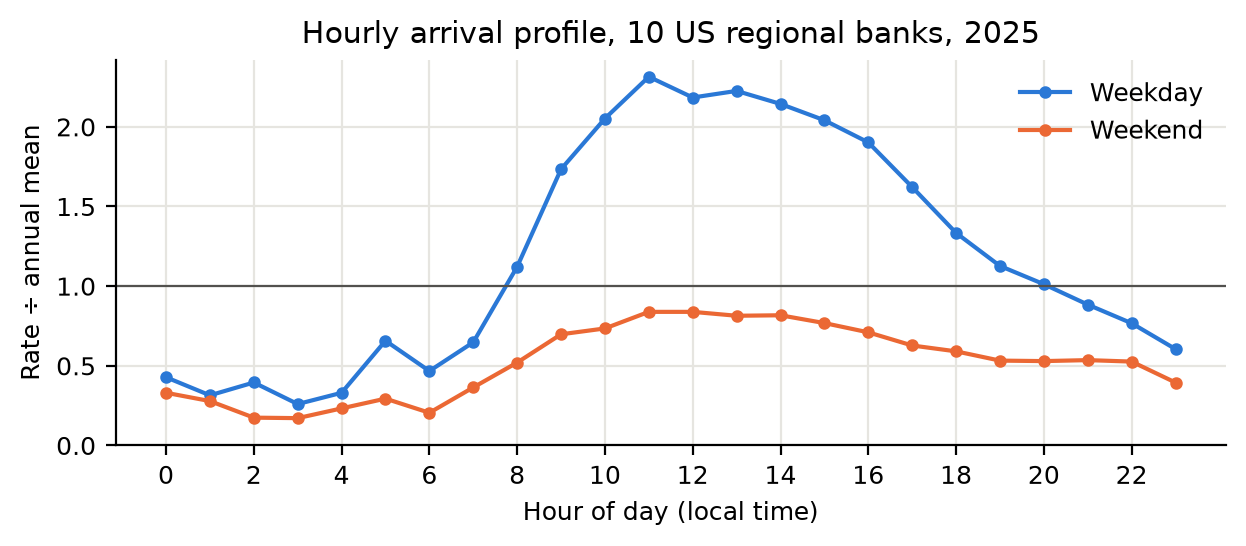

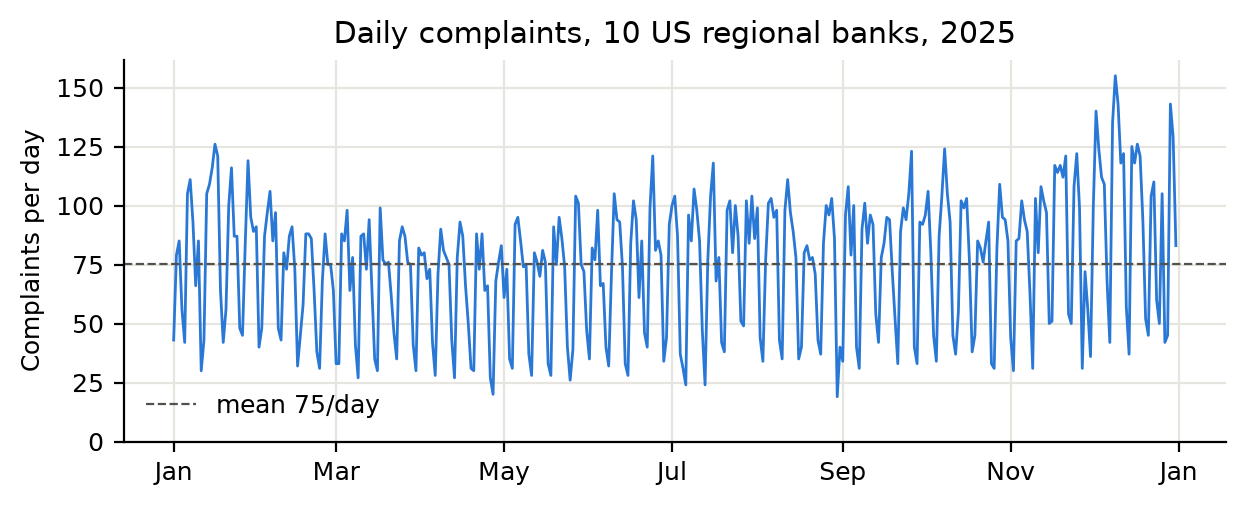

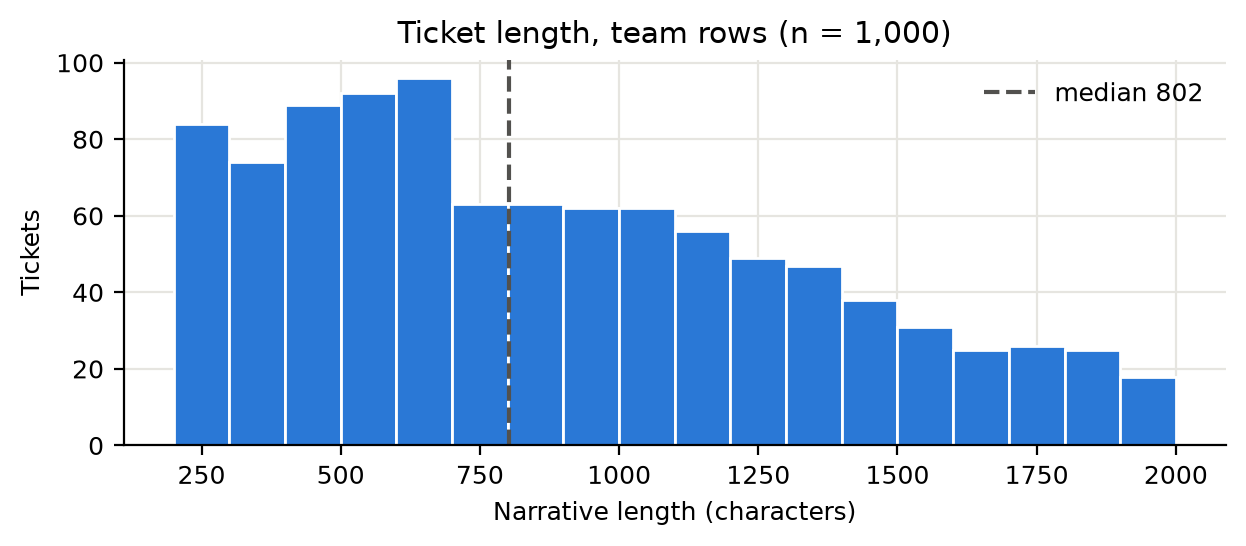

In [8]:
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#52514e"
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e5e0", "axes.axisbelow": True})

fig, ax = plt.subplots(figsize=(6.3, 2.8), dpi=200)
ax.plot(weekday_profile.values, color=BLUE, marker="o", ms=3.5, label="Weekday")
ax.plot(weekend_profile.values, color=ORANGE, marker="o", ms=3.5, label="Weekend")
ax.axhline(1, color=GREY, lw=0.8)
ax.set(xticks=range(0, 24, 2), xlabel="Hour of day (local time)", ylabel="Rate ÷ annual mean",
       ylim=(0, None), title=f"Hourly arrival profile, 10 US regional banks, {YEAR}")
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(FIG_DIR / "hourly_profile.png")

fig, ax = plt.subplots(figsize=(6.3, 2.6), dpi=200)
ax.plot(daily.index, daily.values, color=BLUE, lw=1)
ax.axhline(daily.mean(), color=GREY, lw=0.8, ls="--", label=f"mean {daily.mean():.0f}/day")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set(ylim=(0, None), ylabel="Complaints per day", title=f"Daily complaints, 10 US regional banks, {YEAR}")
ax.legend(frameon=False, loc="lower left")
fig.tight_layout(); fig.savefig(FIG_DIR / "daily_volume.png")

fig, ax = plt.subplots(figsize=(6.3, 2.8), dpi=200)
ax.hist(chars, bins=range(200, 2001, 100), color=BLUE, edgecolor="white")
med = chars.quantile(.5, interpolation="lower")
ax.axvline(med, color=GREY, ls="--", label=f"median {med:.0f}")
ax.set(xlabel="Narrative length (characters)", ylabel="Tickets", title=f"Ticket length, team rows (n = {len(chars):,})")
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(FIG_DIR / "ticket_length.png")